### Hill Climbing (Dynamic Re-Routing)

Hill Climbing is an uninformed greedy search algorithm that does not compute a full path in advance.

Instead, it moves step-by-step toward the goal, always choosing the neighbor with the lowest heuristic value.

In this Flood Evacuation & Rescue System, Hill Climbing is used for dynamic environments where flood conditions may change during movement, allowing real-time re-routing.

## Advantages
1. Very fast (no full search tree)
2. Low memory usage
3. Works well in dynamic environments

## Limitations
1. Can get stuck in local minima
2. No guarantee of shortest path
3. May loop or fail in complex grids

In [1]:
import sys
import os
import heapq
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from Environment.grid import *


VICTIM:
[(1, 1), (4, 2), (2, 9), (6, 2)]

SHELTER:
(18, 18)

FLOOD ORIGINS:
[(9, 9), (9, 10), (10, 9), (10, 10), (11, 9), (11, 10), (12, 9), (12, 10), (15, 8), (15, 9), (16, 8), (16, 9), (17, 8), (17, 9)]

NEIGHBORS OF VICTIM:
(1, 1): [(0, 1), (2, 1), (1, 0), (1, 2)]
(4, 2): [(3, 2), (5, 2), (4, 1), (4, 3)]
(2, 9): [(1, 9), (3, 9), (2, 8), (2, 10)]
(6, 2): [(5, 2), (7, 2), (6, 1), (6, 3)]

CELL INFO (9,9):
{'type': 2, 'water_level': 1.0, 'passable': False}

MOVEMENT COST OF (8,8):
6.0

IS (3,3) PASSABLE?
False


In [2]:
# =====================================================
# HILL CLIMBING (STEP-BY-STEP, SINGLE GOAL)
# =====================================================

def hill_climb_step(current, goal):

    neighbors = get_neighbors(current)

    if not neighbors:
        return None

    best_neighbor = None
    best_score = heuristic(current, goal)

    for neighbor in neighbors:

        score = heuristic(neighbor, goal)

        if score < best_score:
            best_score = score
            best_neighbor = neighbor

    return best_neighbor

In [3]:
# =====================================================
# HILL CLIMBING (STEP-BY-STEP, MULTI GOAL)
# =====================================================

def hill_climb_step_multi(current, goals):

    neighbors = get_neighbors(current)

    if not neighbors:
        return None

    best_neighbor = None
    best_score = heuristic_multi(current, goals)

    for neighbor in neighbors:

        score = heuristic_multi(neighbor, goals)

        if score < best_score:
            best_score = score
            best_neighbor = neighbor

    return best_neighbor

In [4]:
# =====================================================
# HILL CLIMBING SIMULATION WITH FLOOD SPREAD (SINGLE GOAL)
# =====================================================

def hill_climbing_simulation(start, goal, max_steps=100):

    current = start
    path = [current]

    for step in range(max_steps):

        if current == goal:
            print("Goal Reached!")
            break

        if step % 5 == 0:
            spread_flood()

        next_cell = hill_climb_step(current, goal)

        if next_cell is None:

            print("Stuck! No passable neighbor closer to goal.")
            break

        current = next_cell
        path.append(current)

    return path

In [5]:
# =====================================================
# HILL CLIMBING SIMULATION WITH FLOOD SPREAD (MULTI GOAL)
# =====================================================

def hill_climbing_simulation_multi(start, goals, max_steps=100):

    current = start
    path = [current]
    goal_set = set(goals)

    for step in range(max_steps):

        if current in goal_set:
            print("Goal Reached!", current)
            break

        if step % 5 == 0:
            spread_flood()

        next_cell = hill_climb_step_multi(current, goals)

        if next_cell is None:

            print("Stuck! No passable neighbor closer to goal.")
            break

        current = next_cell
        path.append(current)

    return path

In [10]:
# =====================================================
# TEST HILL CLIMBING (MULTI GOAL - START TO VICTIM TO SHELTER)
# =====================================================

start = (0, 0)

# Step 1: Start se nearest victim tak
hill_path_to_victim = hill_climbing_simulation_multi(start, victims)

found_victim_hc = hill_path_to_victim[-1]

# Step 2: Victim se shelter tak (single goal)
hill_path_to_shelter = hill_climbing_simulation(found_victim_hc, shelter)

if hill_path_to_victim and hill_path_to_shelter:

    full_path_hc = hill_path_to_victim + hill_path_to_shelter[1:]

    print("Nearest Victim (Hill Climbing):", found_victim_hc)
    print("Hill Climbing Path to Victim:", len(hill_path_to_victim)-1, "steps")
    print("Hill Climbing Path to Shelter:", len(hill_path_to_shelter)-1, "steps")
    print("Hill Climbing Total Rescue Path:", len(full_path_hc)-1, "steps")

else:

    print("No valid rescue path found.")

Goal Reached! (1, 1)
Stuck! No passable neighbor closer to goal.
Nearest Victim (Hill Climbing): (1, 1)
Hill Climbing Path to Victim: 2 steps
Hill Climbing Path to Shelter: 23 steps
Hill Climbing Total Rescue Path: 25 steps


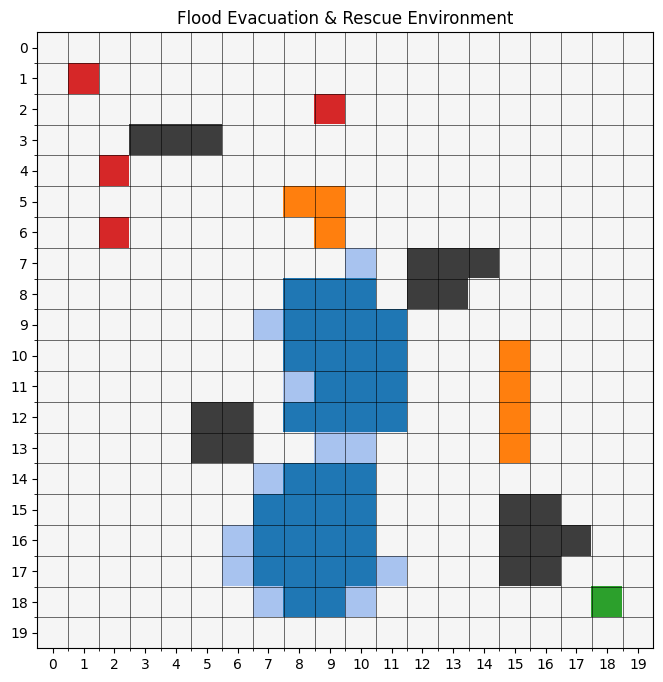

In [16]:
# =====================================================
# STAGE 1: INITIAL GRID
# =====================================================
from Environment.grid import *

display_grid(save_image=False)

In [18]:
# =====================================================
# STAGE 2: HILL CLIMBING PATH TO VICTIM
# =====================================================

def display_hill_climb_path_to_victim(path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="yellow",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 2: Victim Found (Hill Climbing Path)"
    )

    if save_image:

        plt.savefig(
            "../images/hill_climb_stage2_victim_found.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: hill_climb_stage2_victim_found.png"
        )

    plt.show()


Image Saved: hill_climb_stage2_victim_found.png


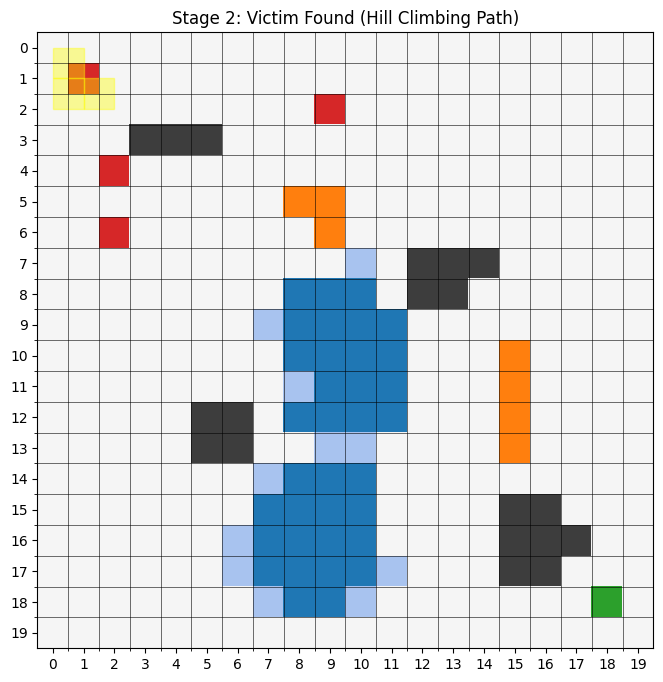

In [19]:
display_hill_climb_path_to_victim(hill_path_to_victim)

In [20]:
# =====================================================
# TEST HILL CLIMBING (VICTIM TO SHELTER)
# =====================================================

hill_path_to_shelter = hill_climbing_simulation(found_victim_hc, shelter)

full_path_hc = hill_path_to_victim + hill_path_to_shelter[1:]

print("\nFULL RESCUE PATH (Hill Climbing):")
print(full_path_hc)

if full_path_hc[-1] == shelter:
    print("\nShelter successfully reached!")
else:
    print("\nStuck before reaching shelter. Stopped at:", full_path_hc[-1])

print("\nTotal Steps:", len(full_path_hc)-1)

Stuck! No passable neighbor closer to goal.

FULL RESCUE PATH (Hill Climbing):
[(0, 0), (1, 0), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (18, 2), (18, 3), (18, 4), (18, 5)]

Stuck before reaching shelter. Stopped at: (18, 5)

Total Steps: 23


In [22]:
# =====================================================
# STAGE 3: FULL RESCUE PATH (VICTIM TO SHELTER) - HILL CLIMBING
# =====================================================

def display_hill_climb_full_rescue_path(full_path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    for r, c in full_path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="green",
                alpha=0.4
            )
        )

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 3: Full Rescue Completed (Hill Climbing)"
    )

    if save_image:

        plt.savefig(
            "../images/hill_climb_stage3_full_rescue.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: hill_climb_stage3_full_rescue.png"
        )

    plt.show()


Image Saved: hill_climb_stage3_full_rescue.png


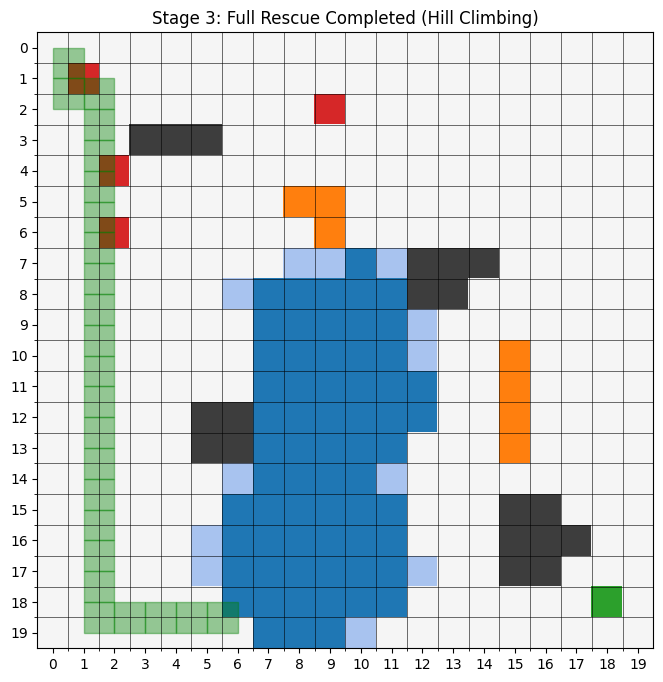

In [23]:
display_hill_climb_full_rescue_path(full_path_hc)